# Dataset preprocessing
Download the dataset from https://huggingface.co/datasets/PaulLerner/21-EuroParl/tree/main/data. Combine the splits into one huge dataset using `prepare_dataset_pandas`.Combine parts of the speeches with the same ID using `collapse()`.

In [2]:
import pandas as pd

In [ ]:
# This method is used to combine parts of the speeches with the same ID.
def collapse(series):
    unique_vals = series.dropna().unique()
    if len(unique_vals) == 1:
        return unique_vals[0]
    else:
        return " ".join(map(str, series))


def prepare_dataset_pandas() -> pd.DataFrame:
    splits = {
        "train": "data/EuroParl/raw/train-00000-of-00001.parquet",
        "dev":   "data/EuroParl/raw/dev-00000-of-00001.parquet",
        "test":  "data/EuroParl/raw/test-00000-of-00001.parquet",
    }

    dfs = [
        pd.read_parquet(path)
        for path in splits.values()
    ]

    df = pd.concat(dfs, ignore_index=True)

    df_grouped = (
        df
        .groupby("speech", as_index=False)
        .agg(collapse)
    )

    df_grouped.drop(columns=["csv_index", "__index_level_0__", "split"], inplace=True)
    
    return df_grouped

def prepare_en_fr_dataset_pandas() -> pd.DataFrame:
    df = pd.read_parquet("data/EuroParl/raw/EN-FR0of2.parquet")
    

In [2]:
df = pd.read_parquet("data/EuroParl/raw/EN-FR0of2.parquet")
df

,translation
0,"{'en': 'Resumption of the session', 'fr': 'Rep..."
1,{'en': 'I declare resumed the session of the E...
2,"{'en': 'Although, as you will have seen, the d..."
3,{'en': 'You have requested a debate on this su...
4,"{'en': 'In the meantime, I should like to obse..."
...,...
1025502,"{'en': '(DE) Madam President, I would like to ..."
1025503,{'en': 'If you look across to the benches of t...
1025504,{'en': 'They themselves are hardly a role mode...
1025505,{'en': 'I would ask that this be specifically ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025507 entries, 0 to 1025506
Data columns (total 1 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   translation  1025507 non-null  object
dtypes: object(1)
memory usage: 7.8+ MB


Next, parse the EU parties and drop speeches from Non-Inscrits (MEPs not affiliated with any party). Finally, save to a .csv file for quicker access with `df = pd.read_csv("data/full.csv")`.

In [ ]:
df = prepare_dataset_pandas()

df["EU Party"] = df["EU Party"].apply(lambda x: x.split('/')[-1])

df = df[~df["EU Party"].str.contains(r"\bNA\b", case=False, na=False)]

df.to_csv("data/EuroParl/preprocessed/full.csv")
len(df)

In [ ]:
df = pd.read_parquet("data/EuroParl/raw/train-00000-of-00001.parquet").groupby("speech", as_index=False).agg(collapse).drop(columns=["csv_index", "__index_level_0__", "split"], inplace=True)
df["EU Party"] = df["EU Party"].apply(lambda x: x.split('/')[-1])

df = df[~df["EU Party"].str.contains(r"\bNA\b", case=False, na=False)]

df.to_csv("data/EuroParl/preprocessed/2009filtered.csv")

# EU Debates dataset preprocessing
TODO - EDIT: Download the dataset from https://huggingface.co/datasets/PaulLerner/21-EuroParl/tree/main/data. Combine the splits into one huge dataset using `prepare_dataset_pandas`.Combine parts of the speeches with the same ID using `collapse()`.

In [10]:
df = pd.read_json("./data/EU Debates/train.jsonl", lines=True)

In [11]:
df = df[df["text"].str.contains(r"group", case=False, na=False)]
df

,speaker_name,speaker_role,speaker_party,intervention_language,original_language,date,year,debate_title,text,translated_text
1,President,EUROPARL President,N/A,en,en,2009-07-14,2009,Election of the President of the European Parl...,"This morning, in accordance with the Rules of ...",None
7,Martin Schulz,MEP,S&D,en,de,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, on behalf of our group I would ...",None
8,Guy Verhofstadt,MEP,ALDE,en,en,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, first of all congratulations fro...",None
9,Rebecca Harms,MEP,Greens/EFA,en,de,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, I would also like to join the p...",None
12,Nigel Farage,MEP,ID,en,en,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, I would like to congratulate you...",None
...,...,...,...,...,...,...,...,...,...,...
106562,Heidi Hautala,MEP,Greens/EFA,en,en,2023-09-14,2023,"Human rights situation in Bangladesh, notably ...","– Mr President, we have been informed an hour...",None
106566,Dita Charanzová,N/A,N/A,en,en,2023-09-14,2023,Composition of committees and delegations,The EPP Group has notified the President of de...,None
106567,Dita Charanzová,N/A,N/A,en,en,2023-09-14,2023,Segregation and discrimination of Roma childre...,The next item is the debate on the oral questi...,None
106569,Elisa Ferreira,N/A,N/A,en,en,2023-09-14,2023,Segregation and discrimination of Roma childre...,"Member of the Commission. – Madam President, ...",None


In [ ]:
df = pd.read_csv("data/EU Debates/preprocessed/filtered.csv")
df["labels"] = df["speaker_party"].astype("category").cat.codes

,Unnamed: 0,speaker_name,speaker_role,speaker_party,intervention_language,original_language,date,year,debate_title,text,translated_text,labels
0,2,Eva-Britt Svensson,MEP,GUE/NGL,en,sv,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, ladies and gentlemen, I would l...",NaN,2
1,3,Jerzy Buzek,MEP,PPE,en,pl,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, representatives of the Council ...",NaN,5
2,6,Joseph Daul,MEP,PPE,en,fr,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, it was unexpected, but it is a ...",NaN,5
3,7,Martin Schulz,MEP,S&D,en,de,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, on behalf of our group I would ...",NaN,6
4,8,Guy Verhofstadt,MEP,ALDE,en,en,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, first of all congratulations fro...",NaN,0
5,9,Rebecca Harms,MEP,Greens/EFA,en,de,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, I would also like to join the p...",NaN,3
6,10,Timothy Kirkhope,MEP,ECR,en,en,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, may I congratulate you on your p...",NaN,1
7,11,Lothar Bisky,MEP,GUE/NGL,en,de,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, I am pleased that a neighbour f...",NaN,2
8,12,Nigel Farage,MEP,ID,en,en,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, I would like to congratulate you...",NaN,4
9,16,József Szájer,MEP,PPE,en,en,2009-07-14,2009,"Election of Vice-Presidents (first, second and...","Mr President, I would like to ask whether ther...",NaN,5


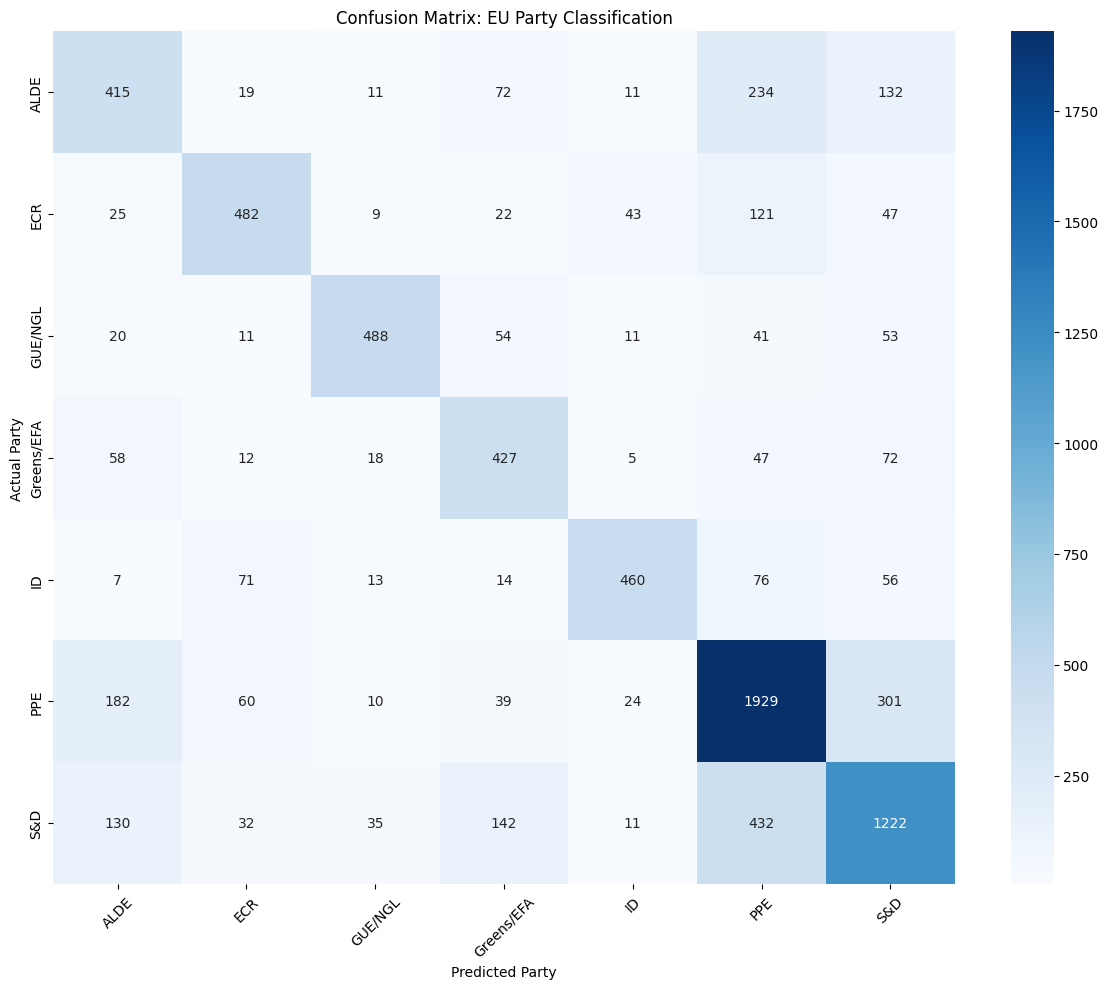

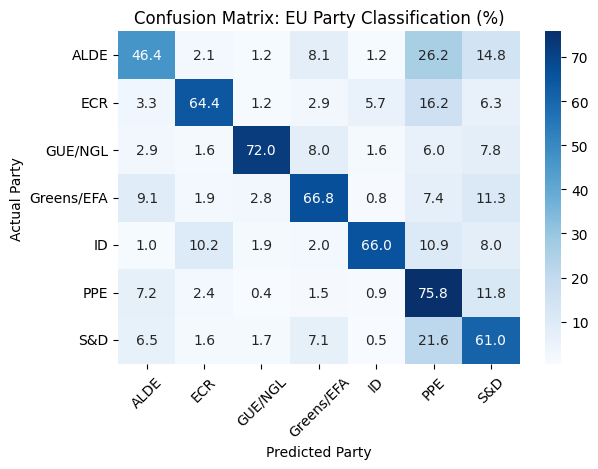

In [16]:
df = pd.read_csv("data/EU Debates/predictions/test_predictions.csv", sep=';', encoding='utf-8-sig')
mapping = {
    0: 'ALDE', 
    1: 'ECR', 
    2: 'GUE/NGL', 
    3: 'Greens/EFA', 
    4: 'ID', 
    5: 'PPE', 
    6: 'S&D'
}
df["predicted_party"]=df['predicted_label'].map(mapping)
df["actual_party"] = df['labels'].map(mapping)
df.to_csv("data/EU Debates/predictions/test_predictions.csv", sep=';', encoding='utf-8-sig', index=False)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix: EU Party Classification')
    plt.ylabel('Actual Party')
    plt.xlabel('Predicted Party')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("data/EU Debates/predictions/confusion_matrix.png")
    plt.show()

def plot_confusion_matrix_p(y_true, y_pred, labels):
    # Calculate the standard confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Convert to percentages: divide each row by the row sum
    # We use .astype('float') to ensure float division
    cm_perc = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100
    
    # Plotting using Seaborn
    # Use fmt='.1f' to show one decimal place for percentages
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title('Confusion Matrix: EU Party Classification (%)')
    plt.ylabel('Actual Party')
    plt.xlabel('Predicted Party')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig("data/EU Debates/predictions/confusion_matrix_percentage.png")

# Generate the plot
plot_confusion_matrix(df['actual_party'], df['predicted_party'], list(mapping.values()))
plot_confusion_matrix_p(df['actual_party'], df['predicted_party'], list(mapping.values()))


In [73]:
df = df[~df["speaker_party"].str.contains(r"\bN/A\b", case=False, na=False)]
df = df[~df["speaker_party"].str.contains(r"\bNI\b", case=False, na=False)]
df.loc[df["translated_text"].notna(), "text"] = df["translated_text"]
print(df["speaker_party"].value_counts()/len(df)*100)
df.to_csv("data/EU Debates/preprocessed/filtered.csv")
df

speaker_party
PPE           31.011285
S&D           24.414410
ALDE          10.891608
ECR            9.131791
ID             8.494406
GUE/NGL        8.262851
Greens/EFA     7.793648
Name: count, dtype: float64


,speaker_name,speaker_role,speaker_party,intervention_language,original_language,date,year,debate_title,text,translated_text
2,Eva-Britt Svensson,MEP,GUE/NGL,en,sv,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, ladies and gentlemen, I would l...",None
3,Jerzy Buzek,MEP,PPE,en,pl,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, representatives of the Council ...",None
6,Joseph Daul,MEP,PPE,en,fr,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, it was unexpected, but it is a ...",None
7,Martin Schulz,MEP,S&D,en,de,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, on behalf of our group I would ...",None
8,Guy Verhofstadt,MEP,ALDE,en,en,2009-07-14,2009,Election of the President of the European Parl...,"Mr President, first of all congratulations fro...",None
...,...,...,...,...,...,...,...,...,...,...
106589,Angel Dzhambazki,MEP,ECR,bg,bg,2023-09-14,2023,Regulation of prostitution in the EU: its cros...,I voted against this report. As some of my th...,I voted against this report. As some of my th...
106590,Rainer Wieland,MEP,PPE,en,en,2023-09-14,2023,"Parliamentarism, European citizenship and demo...","on behalf of the PPE Group. – Madam President,...",None
106591,Angel Dzhambazki,MEP,ECR,bg,bg,2023-09-14,2023,"Parliamentarism, European citizenship and demo...","Mr. President, without any surprise, again op...","Mr. President, without any surprise, again op..."
106592,Clare Daly,MEP,GUE/NGL,en,en,2023-09-14,2023,"Parliamentarism, European citizenship and demo...","– Madam President, I too voted against this f...",None


In [71]:
df_filtered = df[df["text"].str.contains("god", case=False, na=False)]
df_filtered["speaker_party"].value_counts()/len(df)*100

speaker_party
PPE           0.135277
ID            0.123090
GUE/NGL       0.084091
ECR           0.075560
S&D           0.040217
ALDE          0.037780
Greens/EFA    0.018281
Name: count, dtype: float64

In [17]:
df = pd.read_csv("data/EuroParl/scored_llama/full.csv")
print(df["EU Party"].value_counts(), df["EU Party"].astype("category").cat.codes.value_counts())
eu_party_map = {
    'ALDE': 'ALDE',
    'NGL': 'GUE/NGL',
    'PES': 'S&D',
    'EPP-ED': 'PPE',
    'DEM': 'ALDE',
    'EFA': 'Greens/EFA',
    'UEN': 'ECR',
    'EFD': 'ID',
    'EPP': 'PPE',
    'S&D': 'S&D',
    'ECR': 'ECR'
}

df['EU Party'] = df['EU Party'].map(eu_party_map)

EU Party
EPP       4518
S&D       2733
ALDE      1314
NGL       1167
EPP-ED     865
EFA        735
EFD        673
ECR        617
PES        615
UEN        154
DEM        113
Name: count, dtype: int64 5     4518
9     2733
0     1314
7     1167
6      865
3      735
4      673
2      617
8      615
10     154
1      113
Name: count, dtype: int64
